In [1]:
# importeren om te kunnen werken
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import seaborn as sns
import math as math

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

shape_file_area = 7.629080e+03 # in km^2

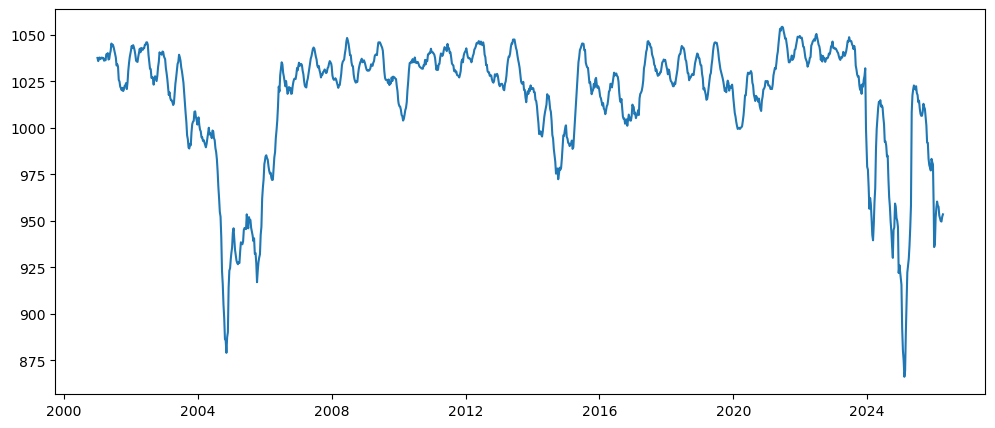

In [2]:
#Route naar oppervlakte
opp_file = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "GWSC_dams_mogwai_Brokopondo.csv"
opp = pd.read_csv(opp_file, delimiter=',', skiprows = 1)
# df = pd.read_csv(discharge_file, delimiter=';', header = 0,  index_col=[0], parse_dates = True)
# df.replace(999000, np.nan, inplace=True)
# print(opp)

opp = opp.rename(columns={"Time (UTC)": "Date"})
# print(opp)
opp["Date"] = pd.to_datetime(opp["Date"], utc = True)
plt.figure(figsize=(12, 5))
plt.plot(opp["Date"], opp["Value"]); #opp werkt in "Date" en "Value voor de datum en de km^2

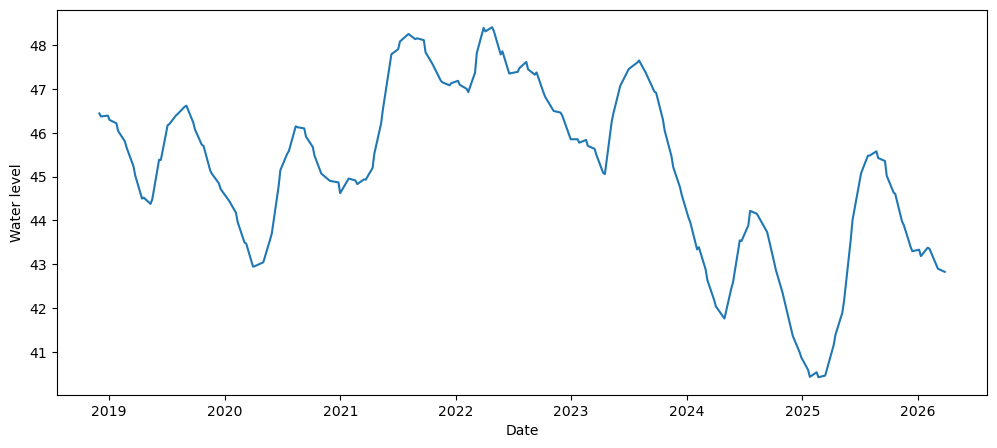

In [3]:
height_file = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "Dahiti Brokopondo water height.xlsx"

# Read malformed Excel
height = pd.read_excel(height_file)

# Split the single column into multiple columns
height = height.iloc[:, 0].str.split(';', expand=True)

# Rename columns
height.columns = ["datetime", "wse", "wse_u"]

# Convert data types
height["datetime"] = pd.to_datetime(height["datetime"], utc=True)
height["wse"] = height["wse"].astype(float)
height["wse_u"] = height["wse_u"].astype(float)

# print(height.head())
# print(height["datetime"])

# Plot
plt.figure(figsize=(12,5))
plt.plot(height["datetime"], height["wse"]) #height werkt in "datetime" en "wse" voor datum en hoogte
plt.xlabel("Date")
plt.ylabel("Water level")
plt.show()

In [4]:
start = max(opp["Date"].min(), height["datetime"].min())
end = min(opp["Date"].max(), height["datetime"].max())
print(start, end)

2018-12-01 01:37:24+00:00 2026-03-27 01:38:37+00:00


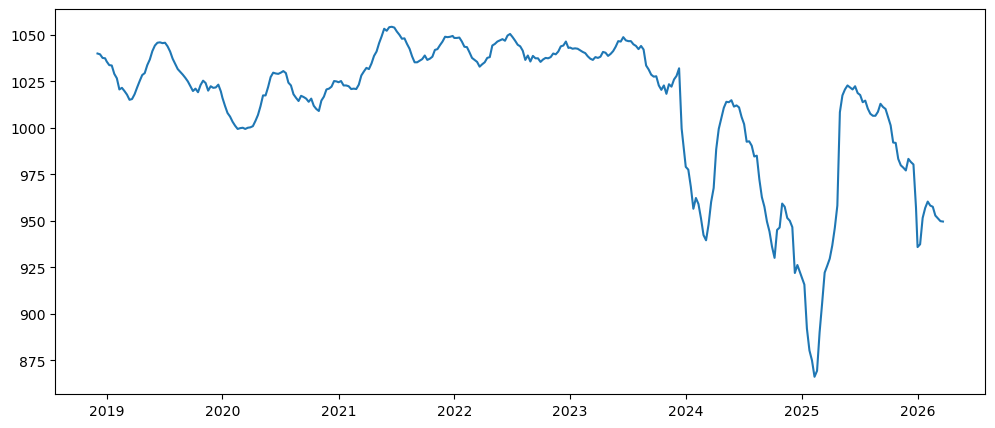

In [5]:
opp = opp[
    (opp["Date"] >= start) &
    (opp["Date"] <= end)
].copy()

plt.figure(figsize=(12, 5))
plt.plot(opp["Date"], opp["Value"]);

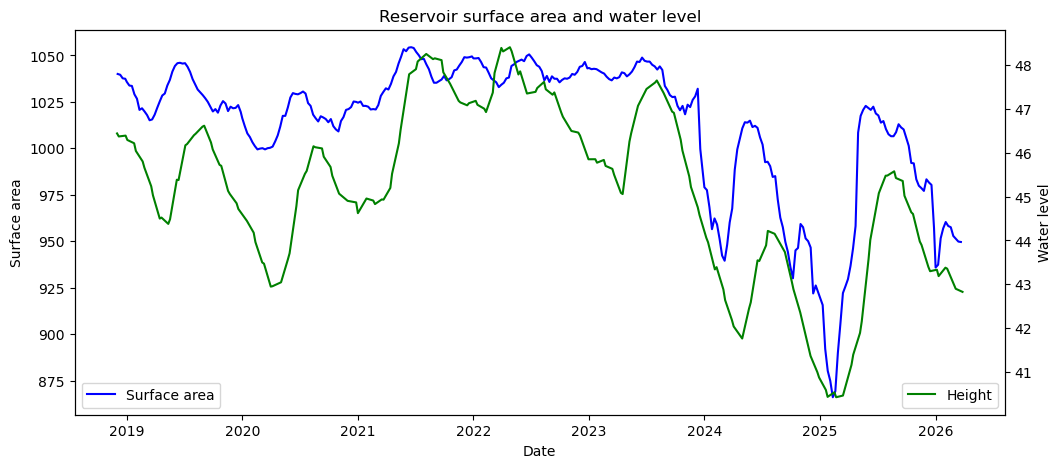

In [6]:
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(opp["Date"], opp["Value"], 'b', label = 'Surface area')
ax1.set_xlabel("Date")
ax1.set_ylabel("Surface area")
plt.legend(loc = 'lower left')

# Right y-axis: water level
ax2 = ax1.twinx()
ax2.plot(height["datetime"], height["wse"], 'g', label = 'Height')
ax2.set_ylabel("Water level")

plt.title("Reservoir surface area and water level")
plt.legend(loc = 'lower right')
plt.show()

In [7]:
print(opp)
print(height)
print(opp["Date"])

                          Date        Value
824  2018-12-03 00:00:00+00:00  1040.018055
825  2018-12-11 00:00:00+00:00  1039.588739
826  2018-12-19 00:00:00+00:00  1037.656817
827  2018-12-27 00:00:00+00:00  1037.442159
828  2019-01-01 00:00:00+00:00  1035.724895
...                        ...          ...
1154 2026-02-18 00:00:00+00:00   957.589380
1155 2026-02-26 00:00:00+00:00   952.866903
1156 2026-03-06 00:00:00+00:00   951.364297
1157 2026-03-14 00:00:00+00:00   949.861691
1158 2026-03-22 00:00:00+00:00   949.647033

[335 rows x 2 columns]
                     datetime     wse  wse_u
0   2018-12-01 01:37:24+00:00  46.442  0.001
1   2018-12-06 13:42:09+00:00  46.373  0.000
2   2018-12-28 01:37:25+00:00  46.392  0.001
3   2019-01-02 13:42:11+00:00  46.293  0.000
4   2019-01-24 01:37:27+00:00  46.218  0.001
..                        ...     ...    ...
173 2026-02-01 01:38:33+00:00  43.377  0.001
174 2026-02-06 13:43:21+00:00  43.355  0.000
175 2026-02-28 01:38:36+00:00  42.989  0.00

In [8]:
# Forcing genereren
basin_name = "Frans"

# tijdsinterval
start_datum = "2018-12-01"
eind_datum = "2024-12-31"
start_datum = pd.to_datetime(start_datum, utc=True)
end_datum = pd.to_datetime(eind_datum, utc=True)
start_pd = start_datum.strftime("%Y-%m-%dT%H:%M:%SZ")
end_pd = end_datum.strftime("%Y-%m-%dT%H:%M:%SZ")
start_datum = start_pd
eind_datum = end_pd

# route naar shape file
shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "boven_suriname.shp"

HBV_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "hbv_bmi"
# HBV_model.mkdir(exist_ok=True)

forcing_route = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "ERA5_SUR_2018_2026"/ "work" / "diagnostic" / "script" / "work" / "diagnostic" / "script"
# forcing_route.mkdir(exist_ok=True)

# genereren
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=start_datum,
#     end_time=eind_datum,
#     shape=shapefile,
#     directory=forcing_route
# )

# inladen
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_route)

print(f"The forcing object you created: \n {ERA5_forcing}")

The forcing object you created: 
 start_time='2018-12-01T00:00:00Z' end_time='2024-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_SUR_2018_2026/work/diagnostic/script/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/ERA5_SUR_2018_2026/work/diagnostic/script/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'OBS6_ERA5_reanaly_1_day_pr_2018-2024.nc', 'tas': 'OBS6_ERA5_reanaly_1_day_tas_2018-2024.nc', 'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_2018-2024.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}


<xarray.DataArray 'evspsblpot' (time: 2557)> Size: 10kB
dask.array<open_dataset-evspsblpot, shape=(2557,), dtype=float32, chunksize=(2557,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 20kB 2018-01-01T12:00:00 ... 2024-12-31T12...
    lat      float64 8B 3.875
    lon      float64 8B -55.75
Attributes:
    standard_name:  water_potential_evaporation_flux
    units:          kg m-2 s-1
    long_name:      potential evaporation
<xarray.DataArray 'pr' (time: 2557)> Size: 10kB
dask.array<open_dataset-pr, shape=(2557,), dtype=float32, chunksize=(2557,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 20kB 2018-01-01T12:00:00 ... 2024-12-31T12...
    lat      float64 8B 3.875
    lon      float64 8B -55.75
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    units:          kg m-2 s-1
    cell_methods:   day_of_year: year: mean latitude: longitude: mean


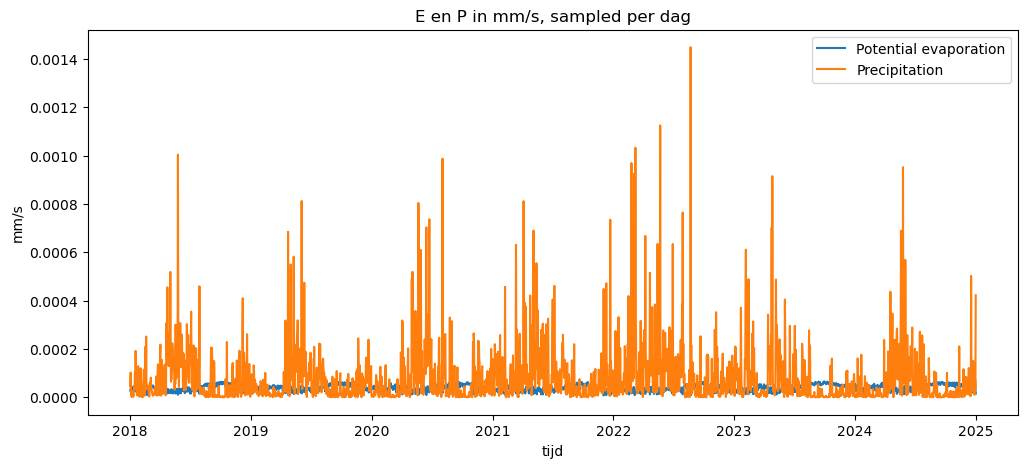

In [9]:
evap = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
print(evap)
print(prec)
fig, ax = plt.subplots(figsize=(12,5))

evap.plot(ax=ax, label='Potential evaporation')
prec.plot(ax=ax, label='Precipitation')
ax.set_ylabel('mm/s')
ax.set_xlabel("tijd")
plt.title("E en P in mm/s, sampled per dag")
ax.legend();

7.1681657e-06 6.588105e-05
-1.9274704e-18 0.001448135


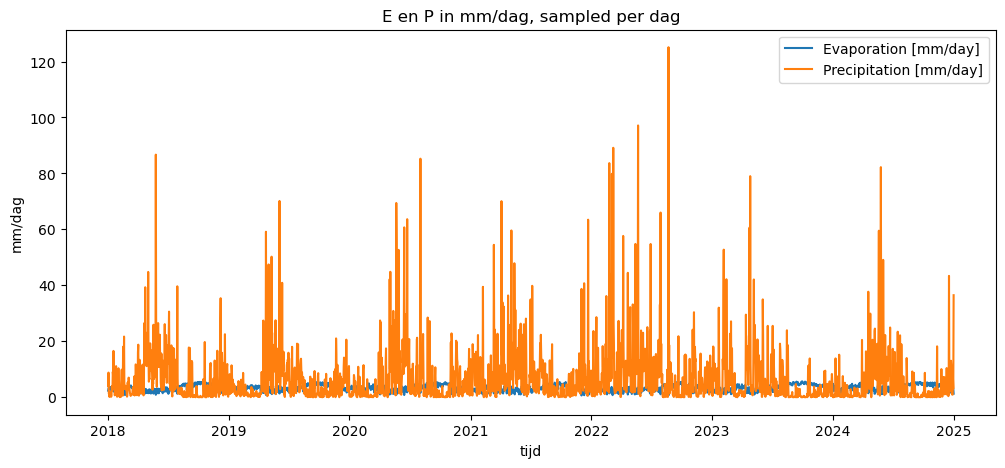

In [10]:
print(evap.min().values, evap.max().values)
print(prec.min().values, prec.max().values)
evap_dag = evap*3600*24
prec_dag = prec*3600*24
fig, ax = plt.subplots(figsize=(12,5))
evap_dag.plot(ax=ax, label="Evaporation [mm/day]")
prec_dag.plot(ax=ax, label="Precipitation [mm/day]")

ax.set_ylabel("mm/dag")
ax.set_xlabel("tijd")
ax.legend()
plt.title("E en P in mm/dag, sampled per dag")
plt.show()

/tmp/ipykernel_1136841/3764873497.py:13: RuntimeWarning: invalid value encountered in scalar power


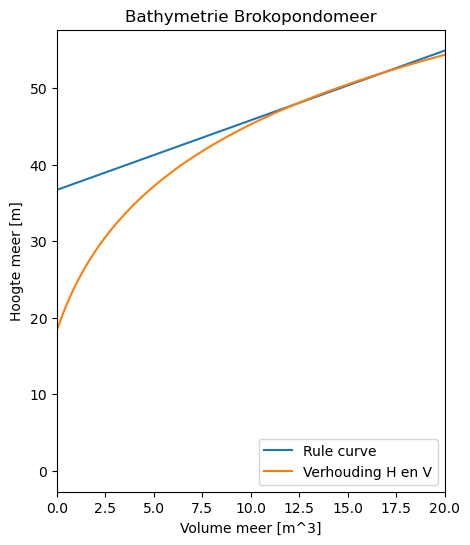

In [11]:
fig, ax1 = plt.subplots(figsize=(5,6))
testH = np.arange(0, 55, 0.1)
testV = np.zeros(len(testH))
for i in range(len(testH)):
    testV[i] = (testH[i] - 36.715)/0.9096
plt.plot(testV, testH, label = "Rule curve")

testHh = np.arange(0, 55, 0.1)
testVv = np.zeros(len(testHh))

for i in range(len(testHh)):
    # testVv[i] = ((testHh[i]-10)/10)**2
    testVv[i] = ((testHh[i]-12)/9.5)**(1/0.45)
# plt.plot(testVv, testHh)

testVvv = np.arange(0,20, 0.03)
testHhh = np.zeros(len(testVvv))
for i in range(len(testVvv)):
    testHhh[i] = 8 + 15*np.log(testVvv[i]+2)
plt.plot(testVvv, testHhh, label = "Verhouding H en V")

plt.xlim(0, 20)
plt.title("Bathymetrie Brokopondomeer")
plt.legend(loc = 'lower right')
ax1.set_xlabel("Volume meer [m^3]")
ax1.set_ylabel("Hoogte meer [m]");

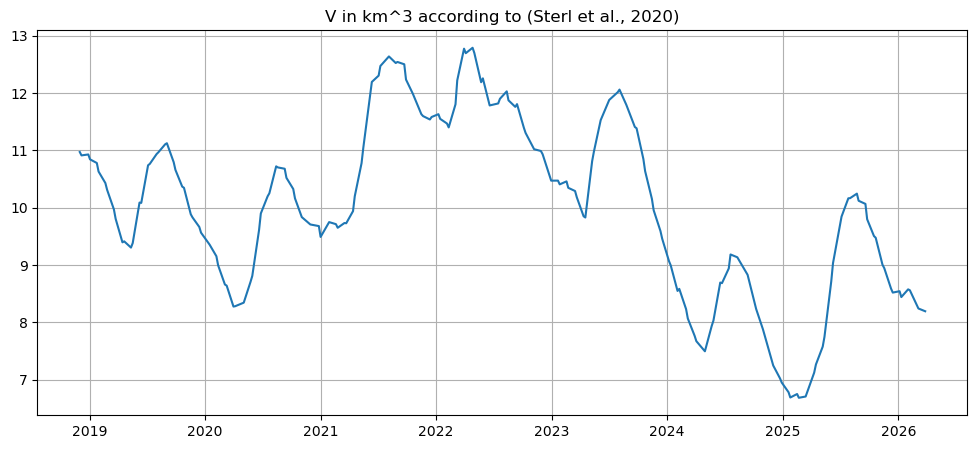

In [12]:
fig, ax1 = plt.subplots(figsize=(12,5))
H = height["wse"]
V = np.zeros(len(H))
# H = 8 + 15*np.log(V+2) met np.log = ln
# V = math.exp((H-8)/15)-2
for i in range(len(H)):
    V[i] = math.exp((H[i]-8)/15)-2
plt.plot(height["datetime"], V)
plt.title("V in km^3 according to (Sterl et al., 2020)")
plt.grid();

2557
178
10.011872989970543
                     datetime        time_diff
0   2018-12-01 01:37:24+00:00              NaT
1   2018-12-06 13:42:09+00:00  5 days 12:04:45
2   2018-12-28 01:37:25+00:00 21 days 11:55:16
3   2019-01-02 13:42:11+00:00  5 days 12:04:46
4   2019-01-24 01:37:27+00:00 21 days 11:55:16
..                        ...              ...
173 2026-02-01 01:38:33+00:00 21 days 11:55:13
174 2026-02-06 13:43:21+00:00  5 days 12:04:48
175 2026-02-28 01:38:36+00:00 21 days 11:55:15
176 2026-03-05 13:43:20+00:00  5 days 12:04:44
177 2026-03-27 01:38:37+00:00 21 days 11:55:17

[178 rows x 2 columns]
0                  NaT
1      5 days 12:04:45
2     21 days 11:55:16
3      5 days 12:04:46
4     21 days 11:55:16
            ...       
173   21 days 11:55:13
174    5 days 12:04:48
175   21 days 11:55:15
176    5 days 12:04:44
177   21 days 11:55:17
Name: time_diff, Length: 178, dtype: timedelta64[ns]


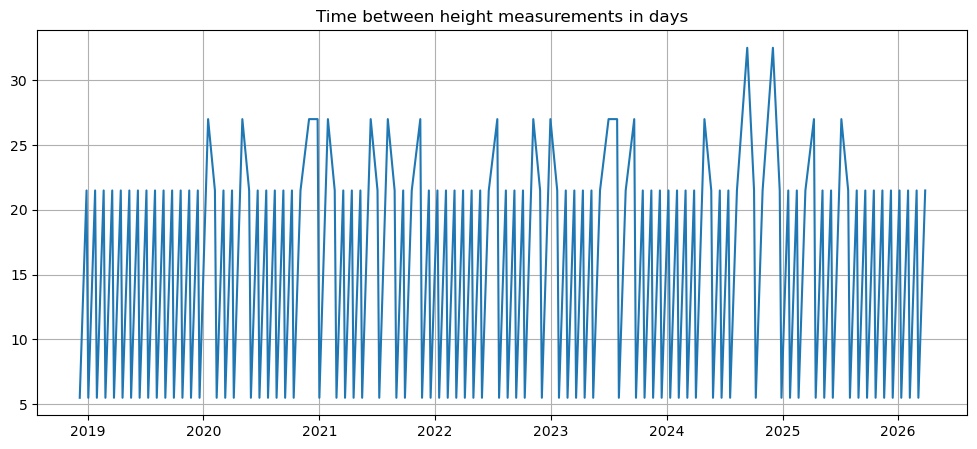

In [13]:
print(len(evap))
print(len(V))
print(V.mean())
fig, ax1 = plt.subplots(figsize=(12,5))
height["time_diff"] = height["datetime"].diff()
print(height[["datetime", "time_diff"]])
print(height["time_diff"])
height["time_diff_hours"] = (
    height["datetime"].diff().dt.total_seconds() / (3600*24)
)
plt.plot(height["datetime"], height["time_diff_hours"])
plt.title("Time between height measurements in days")
plt.grid();

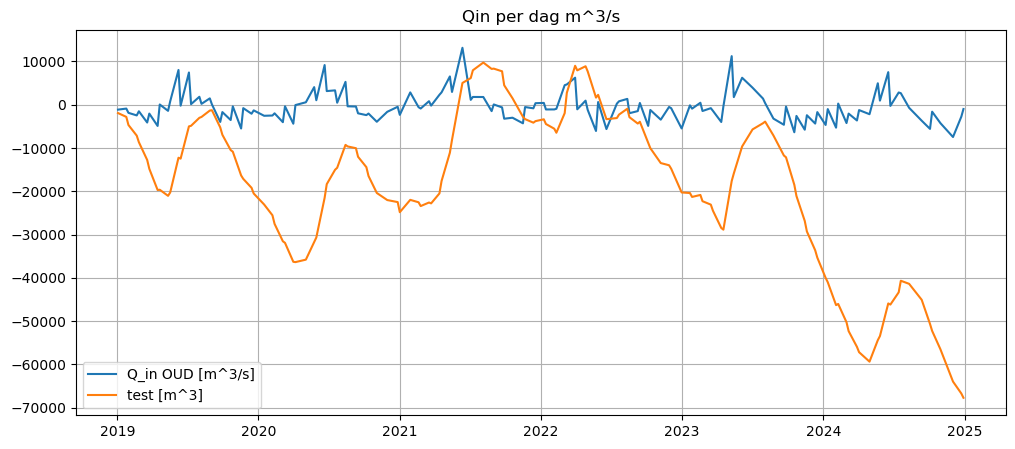

In [14]:
height["datetime_local_none_test"] = height["datetime"].dt.tz_localize(None)
fig, ax1 = plt.subplots(figsize=(12,5))

begin_datum = pd.to_datetime("2019-01-01")
eind_datum = pd.to_datetime("2024-12-31")
evap_dag = evap.sel(time=slice(begin_datum, eind_datum))

height["datetime_local_none_test"] = height["datetime_local_none_test"][
    (height["datetime_local_none_test"] >= begin_datum) & 
    (height["datetime_local_none_test"] <= eind_datum) 
].copy()

Vv = V * 10**9                                                            # van km^3 naar m^3
delta_s = np.zeros(len(height["datetime_local_none_test"]))
E = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L = np.zeros(len(height["datetime_local_none_test"])) 
A = 1000 * 10**6                                                         # makkelijk getal genomen als oppervlakte meer
E_v = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L_sum = np.zeros(len(height["datetime_local_none_test"]))
Q_out = 144.7# m^3/s 

for i in range(len(height["datetime_local_none_test"])-1):
    
    delta_s[i+1] = (Vv[i+1] - Vv[i])* (1/(3600* 24))
    
    t0 = height["datetime_local_none_test"].iloc[i]
    t1 = height["datetime_local_none_test"].iloc[i+1]
    
    evap_interval = evap_dag.sel(time=slice(t0, t1))
    E[i+1] = evap_interval.sum().values * 10**-3 * (1/(3600* 24))        # van mm naar m en van m/d naar m/s
    E_v[i] = A * E[i+1]

    # instroom
    Q_in_L[i+1] = delta_s[i+1] - E_v[i] - Q_out
    Q_in_L[i+1] = np.nan_to_num(Q_in_L[i+1], nan=0.0)
    Q_in_L_sum[i] = Q_in_L.sum()
    Q_in_L_sum_test = np.cumsum(Q_in_L)
    

plt.plot(height["datetime_local_none_test"], Q_in_L, label = "Q_in OUD [m^3/s]");
# plt.plot(height["datetime_local_none_test"], Q_in_L_sum, label = "s [m^3]")
plt.plot(height["datetime_local_none_test"], Q_in_L_sum_test, label = "test [m^3]")
plt.legend()
plt.title("Qin per dag m^3/s")
plt.grid();

# print(len(Q_in_L))
# print("Vv =",Vv)
# print("Q_in_L =",Q_in_L)
# print("delta_s = ",delta_s)
# print("E_v = ",E_v)
# print("Q_out =", Q_out);
# print("Q_in_L.sum =",Q_in_L.sum())

           Date        Value
0    2001-01-01  1037.656817
1    2001-01-09  1035.939553
2    2001-01-17  1037.442159
3    2001-01-25  1037.871475
4    2001-02-02  1037.012843
...         ...          ...
1156 2026-03-06   951.364297
1157 2026-03-14   949.861691
1158 2026-03-22   949.647033
1159 2026-03-30   952.222929
1160 2026-04-07   953.510878

[1161 rows x 2 columns]
dS/dt: -560.0768113339628 878.1902317467101
E_v: 0.0 60.82644611389342
Q_out: 144.7


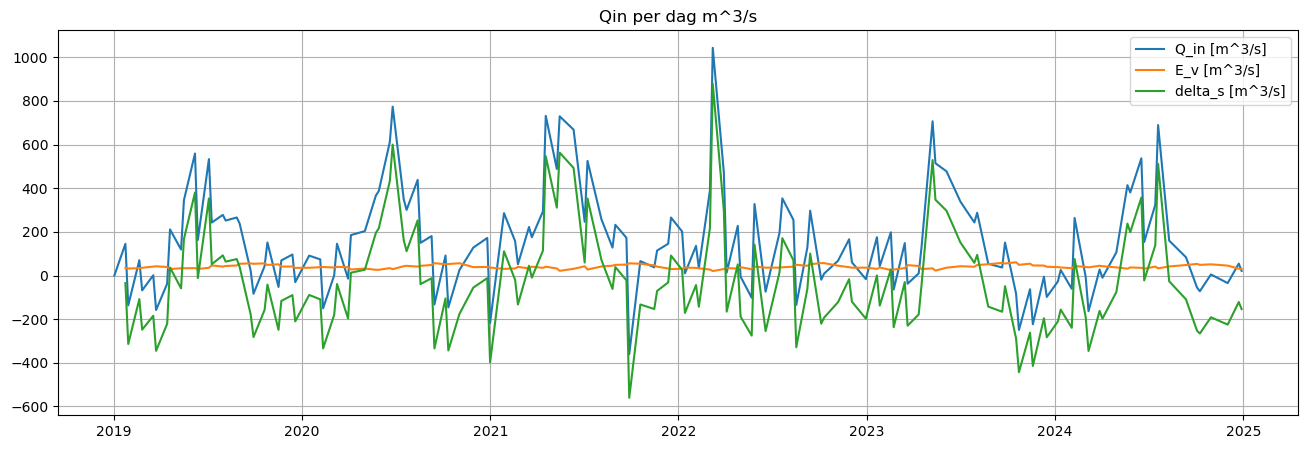

In [24]:
# formule "-" in "+" omgedraaid

height["datetime_local_none_test"] = height["datetime"].dt.tz_localize(None)
fig, ax1 = plt.subplots(figsize=(16,5))

begin_datum = pd.to_datetime("2019-01-01")
eind_datum = pd.to_datetime("2024-12-31")
evap = evap.sel(time=slice(begin_datum, eind_datum))
# print(evap.values)
# print(prec)

height["datetime_local_none_test"] = height["datetime_local_none_test"][
    (height["datetime_local_none_test"] >= begin_datum) &
    (height["datetime_local_none_test"] <= eind_datum)
].copy()
height = height.reset_index(drop=True)

opp = pd.read_csv(opp_file, delimiter=',', skiprows = 1)
opp = opp.rename(columns={"Time (UTC)": "Date"})
opp["Date"] = pd.to_datetime(opp["Date"], utc = True)
opp["Date"] = opp["Date"].dt.tz_localize(None)
print(opp)

area_interp = np.interp(height["datetime_local_none_test"].astype("int64"), opp["Date"].astype("int64"), opp["Value"])

A = 1000 * 10**6                                                         # makkelijk getal genomen als oppervlakte meer

Vv = V * 10**9                                                            # van km^3 naar m^3
delta_s = np.zeros(len(height["datetime_local_none_test"]))
E = np.zeros(len(height["datetime_local_none_test"]))
opper = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L = np.zeros(len(height["datetime_local_none_test"]))
E_v = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L_sum = np.zeros(len(height["datetime_local_none_test"]))
Q_in_L_sum_test = np.zeros(len(height["datetime_local_none_test"]))
Q_out = 144.7# m^3/s 

for i in range(len(height["datetime_local_none_test"])-1):
    
    t0 = height["datetime_local_none_test"].iloc[i]
    t1 = height["datetime_local_none_test"].iloc[i+1]

    # delta_s[i+1] = (Vv[i+1] - Vv[i])* (1/(3600* 24))
    dt_seconds = (t1 - t0).total_seconds()

    delta_s[i+1] = (Vv[i+1] - Vv[i]) / dt_seconds
    
    evap_interval = evap.sel(time=slice(t0, t1))
    E[i+1] = evap_interval.mean().values * 10**-3 #/dt_seconds       # van mm/s naar m/s

    A_t = area_interp[i+1]
    E_v[i+1] = A_t * 1e6 * E[i+1]
    
    # E_v[i+1] = A * E[i+1]

    # instroom
    Q_in_L[i+1] = delta_s[i+1] + E_v[i+1] + Q_out
    Q_in_L[i+1] = np.nan_to_num(Q_in_L[i+1], nan=0.0)
    Q_in_L_sum[i] = Q_in_L.sum()
    Q_in_L_sum_test = np.cumsum(Q_in_L)

plt.plot(height["datetime_local_none_test"], Q_in_L, label = "Q_in [m^3/s]")
plt.plot(height["datetime_local_none_test"], E_v, label = "E_v [m^3/s]")
plt.plot(height["datetime_local_none_test"], delta_s, label = "delta_s [m^3/s]")
# plt.plot(height["datetime_local_none_test"], area_interp, label = "opp [m^3/s]")
# plt.plot(height["datetime_local_none_test"], Q_in_L_sum_test, label = "sum [m^3]")
plt.legend()
plt.title("Qin per dag m^3/s")
plt.grid();

# print(len(Q_in_L))
# print("Vv =",Vv)
# print("Q_in_L =",Q_in_L)
# print("delta_s = ",delta_s)
# print("E_v = ",E_v)
# print("Q_out =", Q_out);
# print("Q_in_L.sum =",Q_in_L.sum())
# print(Q_in_L)
# print(Q_in_L_sum)
print("dS/dt:", np.nanmin(delta_s), np.nanmax(delta_s))
print("E_v:", np.nanmin(E_v), np.nanmax(E_v))
print("Q_out:", Q_out)

In [16]:
print("dS/dt:", np.nanmin(delta_s), np.nanmax(delta_s))
print("E_v:", np.nanmin(E_v), np.nanmax(E_v))
print("Q_out:", Q_out)

dS/dt: -560.0768113339628 878.1902317467101
E_v: 0.0 60.82644611389342
Q_out: 144.7


In [17]:
print(opp)

           Date        Value
0    2001-01-01  1037.656817
1    2001-01-09  1035.939553
2    2001-01-17  1037.442159
3    2001-01-25  1037.871475
4    2001-02-02  1037.012843
...         ...          ...
1156 2026-03-06   951.364297
1157 2026-03-14   949.861691
1158 2026-03-22   949.647033
1159 2026-03-30   952.222929
1160 2026-04-07   953.510878

[1161 rows x 2 columns]


In [18]:
def level(Qin, Qout, ERA5_forcing, A):
    #Qin is array met discharge van rivier in meer, gebaseerd op E en P en dagelijks
    #Qout is een standaard baseflow uit het meer
    #E is verdampingsdata van ERA5, dagelijks
    #A is oppervlakte meer in m^2 
    
    dt = 3600*24
    E = ERA5_forcing.to_xarray()["evspsblpot"] * dt
    L = np.zeros(len(E))
    
    for i in range(len(E)):
        dL = (Qin[i] - Qout - E[i]) / A
        L[i] = L[i-1] + dL*dt
    return L

In [19]:
def discharge(parameters, forcing):
    # parameters zijn;
    #   Qgw - ground water flow in eht meer
    #   alpha - neerslag/verdamping coefficient
    #   beta - neerslag/verdamping coefficient
    ERA5_forcing = forcing

    E_da = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
    P_da = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag

    Qg, alpha, beta = parameters

    dt = 86400

    Qin = []

    for current_timestep in range(len(P_da)):

        P = P_da.isel(time=current_timestep).to_numpy() * dt
        E = E_da.isel(time=current_timestep).to_numpy() * dt

        Q = Qg + alpha * (P - E)**beta

        Qin.append(Q)

    return Qin # in m^3/s

In [20]:
param = [0, 1, 1]
Qg, alpha, beta = param
print(beta)

1


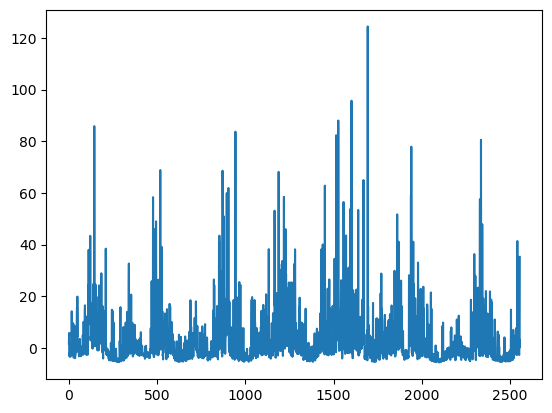

In [21]:
a = discharge(param, ERA5_forcing)
x = np.arange(0, len(a))
plt.plot(x, a)

In [22]:
Qin = discharge(param, ERA5_forcing)
Qout = 144.7
A = shape_file_area
b = level(Qin, Qout, ERA5_forcing, A)

In [23]:
print(b)

[-1.64634951e+03 -3.25515505e+03 -4.95734292e+03 ... -4.19388624e+06
 -4.19555705e+06 -4.19681128e+06]
